# Convolutional Neural Network (CNN) Classification - CIFAR-10 Image Classification

This project develops a Convolutional Neural Network (CNN) to classify natural RGB images from the CIFAR-10 dataset. The workflow covers data loading, preprocessing, model development, training, evaluation, and prediction analysis using TensorFlow/Keras.

## 1. Import Required Libraries

Import all required libraries.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix

tf.keras.utils.set_random_seed(42)

## 2. Load Dataset

Load the CIFAR-10 dataset from TensorFlow/Keras.

In [2]:
(x_train,y_train),(x_test,y_test)=cifar10.load_data()
class_names=['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

## 3. Explore Dataset

Visualize sample images.

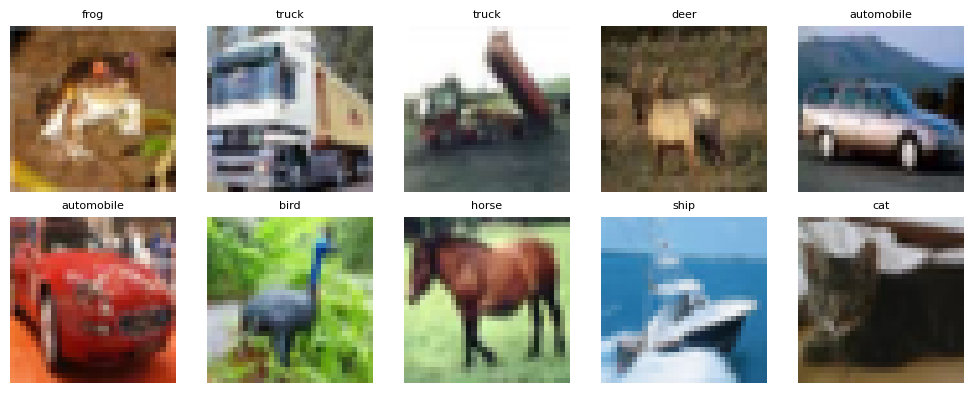

In [3]:
fig,axs=plt.subplots(2,5,figsize=(10,4))
for i,ax in enumerate(axs.flat):
 ax.imshow(x_train[i]); ax.set_title(class_names[y_train[i][0]],fontsize=8); ax.axis('off')
plt.tight_layout(); plt.show()

## 4. Preprocess Images

Normalize pixel values.

In [4]:
x_train=x_train.astype('float32')/255.0
x_test=x_test.astype('float32')/255.0

## 5. Build CNN Model

Create the CNN architecture.

In [5]:
model=models.Sequential([
 layers.Input((32,32,3)),
 layers.Conv2D(32,3,padding='same',activation='relu'),
 layers.Conv2D(32,3,activation='relu'),
 layers.MaxPooling2D(),
 layers.Dropout(0.25),
 layers.Conv2D(64,3,padding='same',activation='relu'),
 layers.Conv2D(64,3,activation='relu'),
 layers.MaxPooling2D(),
 layers.Dropout(0.25),
 layers.Flatten(),
 layers.Dense(256,activation='relu'),
 layers.Dropout(0.5),
 layers.Dense(10,activation='softmax')])
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 658,218 (2.51 MB)

 Trainable params: 658,218 (2.51 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Train the Model

Train with early stopping.

In [6]:
early=EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)
history=model.fit(x_train,y_train,epochs=30,batch_size=64,validation_split=0.2,callbacks=[early])

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 92ms/step - accuracy: 0.3898 - loss: 1.6553 - val_accuracy: 0.5279 - val_loss: 1.3158
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 100ms/step - accuracy: 0.5512 - loss: 1.2603 - val_accuracy: 0.6207 - val_loss: 1.0559
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 107ms/step - accuracy: 0.6143 - loss: 1.0919 - val_accuracy: 0.6676 - val_loss: 0.9250
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 73s 117ms/step - accuracy: 0.6510 - loss: 0.9829 - val_accuracy: 0.6865 - val_loss: 0.8685
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 104ms/step - accuracy: 0.6787 - loss: 0.9158 - val_accuracy: 0.7154 - val_loss: 0.8101
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 101ms/step - accuracy: 0.7040 - loss: 0.8465 - val_accuracy: 0.7296 - val_loss: 0.7654
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 98ms/step - accuracy: 0.7156 - loss: 0.8091 - val_accuracy: 0.7463 - val_loss: 0.7308
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 75ms/step - accuracy: 0.7291 - loss: 0.76

## 7. Training Curves

Plot training history.

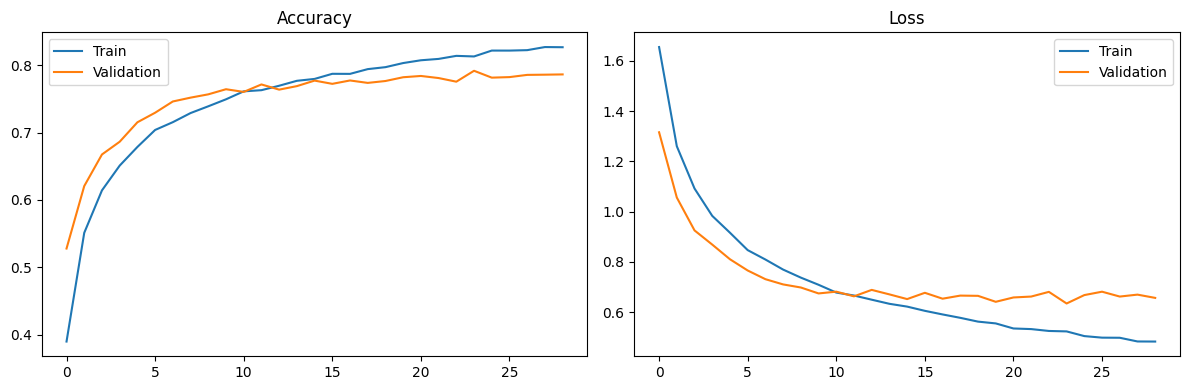

In [7]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1); plt.plot(history.history['accuracy']); plt.plot(history.history['val_accuracy']); plt.legend(['Train','Validation']); plt.title('Accuracy')
plt.subplot(1,2,2); plt.plot(history.history['loss']); plt.plot(history.history['val_loss']); plt.legend(['Train','Validation']); plt.title('Loss')
plt.tight_layout(); plt.show()

## 8. Evaluate Model

Evaluate on the test set.

In [8]:
test_loss,test_acc=model.evaluate(x_test,y_test,verbose=0)
print(f'Test Accuracy: {test_acc:.4f}')
pred=np.argmax(model.predict(x_test,verbose=0),axis=1)

Test Accuracy: 0.7786


## 9. Classification Report

Generate classification metrics.

In [9]:
print(classification_report(y_test,pred,target_names=class_names))

              precision    recall  f1-score   support

    airplane       0.76      0.83      0.80      1000
  automobile       0.91      0.88      0.90      1000
        bird       0.70      0.65      0.67      1000
         cat       0.62      0.58      0.60      1000
        deer       0.77      0.71      0.74      1000
         dog       0.70      0.72      0.71      1000
        frog       0.82      0.84      0.83      1000
       horse       0.77      0.86      0.81      1000
        ship       0.88      0.85      0.87      1000
       truck       0.84      0.86      0.85      1000

    accuracy                           0.78     10000
   macro avg       0.78      0.78      0.78     10000
weighted avg       0.78      0.78      0.78     10000



## 10. Confusion Matrix

Visualize prediction performance.

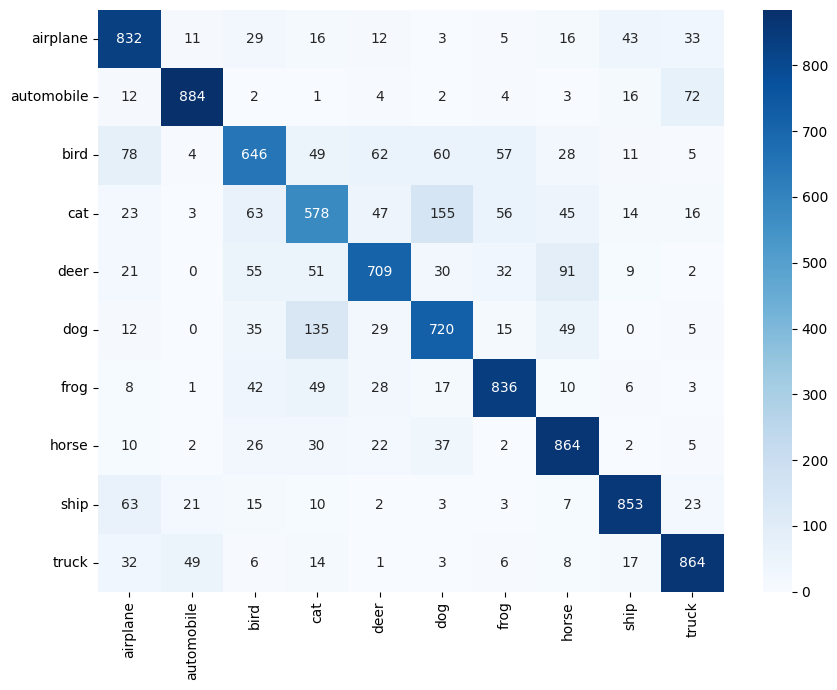

In [10]:
cm=confusion_matrix(y_test,pred)
plt.figure(figsize=(9,7)); sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=class_names,yticklabels=class_names); plt.tight_layout(); plt.show()

## 11. Sample Predictions

Display sample predictions.

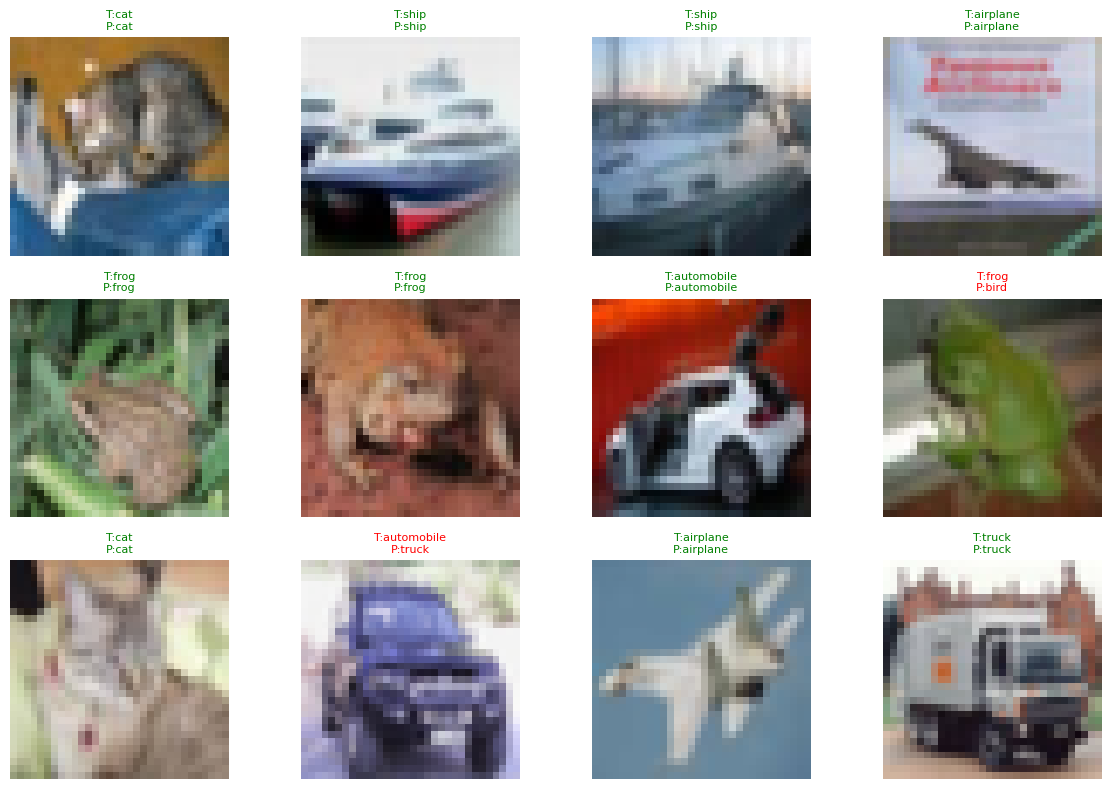

In [11]:
plt.figure(figsize=(12,8))
for i in range(12):
 plt.subplot(3,4,i+1); plt.imshow(x_test[i]); plt.title(f'T:{class_names[y_test[i][0]]}\nP:{class_names[pred[i]]}',fontsize=8,color=('green' if pred[i]==y_test[i][0] else 'red')); plt.axis('off')
plt.tight_layout(); plt.show()

## 12. Key Findings

The CNN achieved a test accuracy of **77.86%** on the CIFAR-10 dataset, demonstrating its ability to learn meaningful visual features from natural RGB images. Training and validation accuracy followed similar trends, indicating good generalization with only mild overfitting.

The model performed particularly well on visually distinctive classes such as automobiles, trucks, horses, and frogs. Lower performance was observed for classes including cats, birds, and dogs, reflecting the greater visual similarity between these categories.

Overall, the project establishes a strong baseline CNN for image classification and provides a solid foundation for more advanced computer vision techniques such as transfer learning.

## 13. Conclusion

This project successfully implemented a Convolutional Neural Network (CNN) for multi-class image classification using the CIFAR-10 dataset. The complete workflow covered data preprocessing, model development, training, evaluation, and prediction analysis.

The final model achieved a test accuracy of **77.86%**, demonstrating reliable performance for a custom CNN trained from scratch. While there is room for improvement through techniques such as data augmentation, batch normalization, and transfer learning, this implementation provides a strong baseline model and effectively demonstrates the core principles of convolutional neural networks.